# DTLZ2: Comparação Criteriosa entre Três Implementações do NSGA-II (e o NSGA-III como referência)

**Otimização Multiobjetivo Evolutiva — material de estudo**

Companheiro do notebook [dtlz2-nsga-comparison](dtlz2-nsga-comparison.ipynb) (focado no NSGA-III), este
estudo compara, sobre o **DTLZ2**, três implementações do **NSGA-II** e usa o NSGA-III próprio como
**referência de qualidade** ("o que dá para alcançar" em 3 objetivos):

| Rótulo | Algoritmo | Origem |
|---|---|---|
| `NSGA-II` | NSGA-II | implementação própria — [`modules/nsga2`](../../modules/nsga2/nsga2.py) |
| `NSGA-II (DEAP)` | NSGA-II | biblioteca [DEAP](https://github.com/DEAP/deap) — [`modules/nsga2_deap`](../../modules/nsga2_deap/nsga2_deap.py) |
| `NSGA-II (pymoo)` | NSGA-II | biblioteca [pymoo](https://pymoo.org) — [`modules/nsga2_pymoo`](../../modules/nsga2_pymoo/nsga2_pymoo.py) |
| `NSGA-III (ref.)` | NSGA-III | implementação própria — [`modules/nsga3`](../../modules/nsga3/nsga3.py) |

As quatro recebem **os mesmos operadores genéticos, a mesma população inicial e os mesmos hiperparâmetros**.
Duas perguntas guiam o estudo:

1. As três implementações de **NSGA-II** concordam entre si? (Se sim, a implementação própria está correta e
   o desempenho reflete o **algoritmo**, não um bug.)
2. Quanto o **NSGA-II** fica atrás do **NSGA-III** em 3 objetivos — e por quê?

Além disso, **analisamos e corrigimos a implementação própria do NSGA-II** (Seção 5).

## Roteiro

1. **Problema DTLZ2** — definição e fronteira de Pareto analítica.
2. **Operadores genéticos** — SBX com limites e mutação polinomial.
3. **Mecanismos de diversidade** — *crowding distance* (NSGA-II) vs direções de referência (NSGA-III).
4. **Métricas de qualidade** — GD, IGD e Hipervolume.
5. **As quatro implementações e as correções no NSGA-II próprio**.
6. **Execução detalhada** (uma semente) — gráficos 3D, projeções 2D e coordenadas paralelas.
7. **Comparação estatística** (várias sementes) — tabela-resumo e barras com desvio.
8. **NSGA-II na sua zona de conforto** — o mesmo estudo com $M=2$ objetivos.
9. **Discussão e conclusões**.

## 1. O problema DTLZ2

O **DTLZ2** (Deb, Thiele, Laumanns & Zitzler, 2002) é um problema-teste escalável de minimização com
$M$ objetivos e $n = M - 1 + k$ variáveis de decisão em $[0,1]$. As $M-1$ primeiras variáveis **posicionam**
a solução na fronteira; as $k$ últimas (agrupadas em $x_M$) controlam a **distância** à fronteira via

$$
g(x_M) = \sum_{x_i \in x_M} (x_i - 0.5)^2 ,
$$

e os objetivos são $f_m(x) = (1+g)\,\big[\text{produto de cossenos/senos de } \tfrac{\pi}{2}x_i\big]$. O mínimo
$g=0$ ocorre com $x_i = 0.5$; nesse caso $\sum_m f_m^2 = 1$, ou seja, **a fronteira de Pareto é o octante da
esfera unitária**. Isso separa duas dificuldades: **convergir** ($g \to 0$) e **distribuir-se** sobre a
superfície curva. Usamos $M=3$, $k=10$ ($n=12$) — a mesma configuração do notebook do NSGA-III.

In [1]:
import sys, os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # habilita projeção 3D

project_path = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if project_path not in sys.path:
    sys.path.insert(0, project_path)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [2]:
# ----- Parâmetros globais do experimento (estudo principal: M = 3) -----
M      = 3
K      = 10
N_VAR  = M - 1 + K          # = 12
bounds = [(0.0, 1.0)] * N_VAR

POP_SIZE = 66
N_GEN    = 60
DIV      = 10               # divisões das-dennis p/ as direções de referência do NSGA-III de referência

SEEDS  = list(range(1, 12)) # 11 repetições independentes
SEED_DEMO = 1

REF_HV = np.array([1.1] * M)   # ponto de referência do hipervolume

In [3]:
def dtlz2(x: np.ndarray, M: int = M) -> np.ndarray:
    '''DTLZ2 (minimização). Recebe x em [0,1]^n e devolve o vetor de M objetivos.'''
    x = np.asarray(x, dtype=float)
    n = x.size
    k = n - (M - 1)
    g = float(np.sum((x[n - k:] - 0.5) ** 2))
    f = np.empty(M, dtype=float)
    for m in range(M):
        val = 1.0 + g
        for i in range(M - m - 1):
            val *= np.cos(0.5 * np.pi * x[i])
        if m > 0:
            val *= np.sin(0.5 * np.pi * x[M - m - 1])
        f[m] = val
    return f

# O NSGA-II próprio espera uma LISTA de funções escalares; as demais aceitam a função vetorial.
dtlz2_objectives = [(lambda x, m=m: float(dtlz2(x)[m])) for m in range(M)]

_probe = np.full(N_VAR, 0.5); _probe[0] = 0.3
print("f(x*) =", np.round(dtlz2(_probe), 4), " | norma =", round(float(np.linalg.norm(dtlz2(_probe))), 6))

f(x*) = [0.63  0.63  0.454]  | norma = 1.0


### 1.1 Fronteira de Pareto analítica

Amostramos densamente a fronteira exata (octante da esfera para $M=3$; quarto de circunferência para $M=2$)
e a usamos como conjunto de referência $P^*$ para GD e IGD.

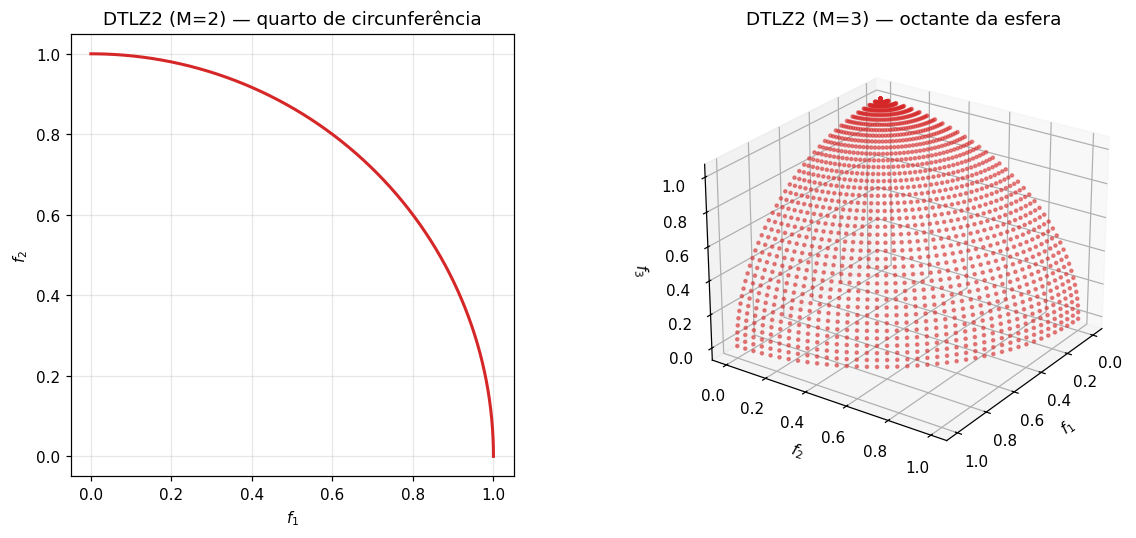

In [4]:
def true_pf_m2(n=400):
    t = np.linspace(0, np.pi/2, n)
    return np.cos(t), np.sin(t)

def true_pf_m3(n=40):
    '''Octante da esfera unitária: fronteira de Pareto exata do DTLZ2 (M=3).'''
    th = np.linspace(0, np.pi/2, n)
    ph = np.linspace(0, np.pi/2, n)
    T, P = np.meshgrid(th, ph, indexing="ij")
    return np.vstack([(np.cos(T)*np.cos(P)).ravel(),
                      (np.cos(T)*np.sin(P)).ravel(),
                      np.sin(T).ravel()]).T

PF_TRUE = true_pf_m3(40)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1)
x2, y2 = true_pf_m2()
ax1.plot(x2, y2, lw=2, color="tab:red")
ax1.set_title("DTLZ2 (M=2) — quarto de circunferência")
ax1.set_xlabel("$f_1$"); ax1.set_ylabel("$f_2$"); ax1.set_aspect("equal")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(PF_TRUE[:, 0], PF_TRUE[:, 1], PF_TRUE[:, 2], s=4, alpha=0.5, color="tab:red")
ax2.set_title("DTLZ2 (M=3) — octante da esfera")
ax2.set_xlabel("$f_1$"); ax2.set_ylabel("$f_2$"); ax2.set_zlabel("$f_3$")
ax2.view_init(elev=25, azim=35)
plt.tight_layout(); plt.show()

## 2. Operadores genéticos

Todas as implementações compartilham os mesmos operadores de variação, para que a diferença esteja no
**mecanismo de seleção/diversidade**, não nos operadores:

- **SBX — Simulated Binary Crossover** (Deb & Agrawal, 1995), gene a gene, com os filhos **projetados de
  volta para $[0,1]$** (*clip*). Sem o *clip*, com $k=10$ as variáveis saem dos limites e $g$ explode.
- **Mutação polinomial** (Deb, 2001), probabilidade $1/n$ por variável.

In [5]:
Vector = np.ndarray
Bounds = list

ETA_C = 15.0
ETA_M = 20.0

def crossover(parent1: Vector, parent2: Vector) -> tuple[Vector, Vector]:
    '''SBX gene a gene, com filhos projetados de volta para [0, 1].'''
    n = parent1.shape[0]
    c1 = np.empty_like(parent1); c2 = np.empty_like(parent2)
    for i in range(n):
        x1, x2 = parent1[i], parent2[i]
        if random.random() < 0.5 and abs(x1 - x2) > 1e-14:
            if x1 > x2:
                x1, x2 = x2, x1
            u = random.random()
            if u <= 0.5:
                beta_q = (2.0 * u) ** (1.0 / (ETA_C + 1.0))
            else:
                beta_q = (1.0 / (2.0 * (1.0 - u))) ** (1.0 / (ETA_C + 1.0))
            a = 0.5 * ((x1 + x2) - beta_q * (x2 - x1))
            b = 0.5 * ((x1 + x2) + beta_q * (x2 - x1))
            c1[i] = min(max(a, 0.0), 1.0)
            c2[i] = min(max(b, 0.0), 1.0)
        else:
            c1[i], c2[i] = x1, x2
    return c1, c2

def mutation(individual: Vector, bounds: Bounds) -> Vector:
    '''Mutação polinomial com probabilidade 1/n por variável.'''
    n = individual.shape[0]
    pm = 1.0 / n
    y = individual.copy()
    for i in range(n):
        if random.random() < pm:
            yl, yu = bounds[i]
            if yu <= yl:
                continue
            yi = y[i]
            d1 = (yi - yl) / (yu - yl)
            d2 = (yu - yi) / (yu - yl)
            r = random.random()
            mp = 1.0 / (ETA_M + 1.0)
            if r < 0.5:
                deltaq = (2.0 * r + (1.0 - 2.0 * r) * (1.0 - d1) ** (ETA_M + 1.0)) ** mp - 1.0
            else:
                deltaq = 1.0 - (2.0 * (1.0 - r) + 2.0 * (r - 0.5) * (1.0 - d2) ** (ETA_M + 1.0)) ** mp
            y[i] = np.clip(yi + deltaq * (yu - yl), yl, yu)
    return y

## 3. Mecanismos de diversidade: *crowding distance* vs direções de referência

A diferença central entre os dois algoritmos está em **como preservam diversidade** dentro da fronteira que
precisa ser dividida na seleção ambiental:

- **NSGA-II — *crowding distance*.** Para cada objetivo, ordenam-se as soluções da fronteira e soma-se, por
  solução, a distância (normalizada) entre seus dois **vizinhos**. Soluções em regiões pouco povoadas ganham
  distância maior e são preferidas. É barato e não exige parâmetros, mas em **muitos objetivos** a noção de
  "vizinho" se dilui e a pressão por diversidade enfraquece — a motivação histórica para o NSGA-III.
- **NSGA-III — direções de referência.** Distribuem-se direções uniformes sobre o simplexo (malha
  *das-dennis*) e cada solução é associada à direção mais próxima; a seleção preserva a cobertura dessas
  direções. Escala bem para $M \ge 3$.

A figura abaixo ilustra a *crowding distance* (o "cubóide" entre os vizinhos de uma solução) e as direções de
referência usadas pelo NSGA-III de referência.

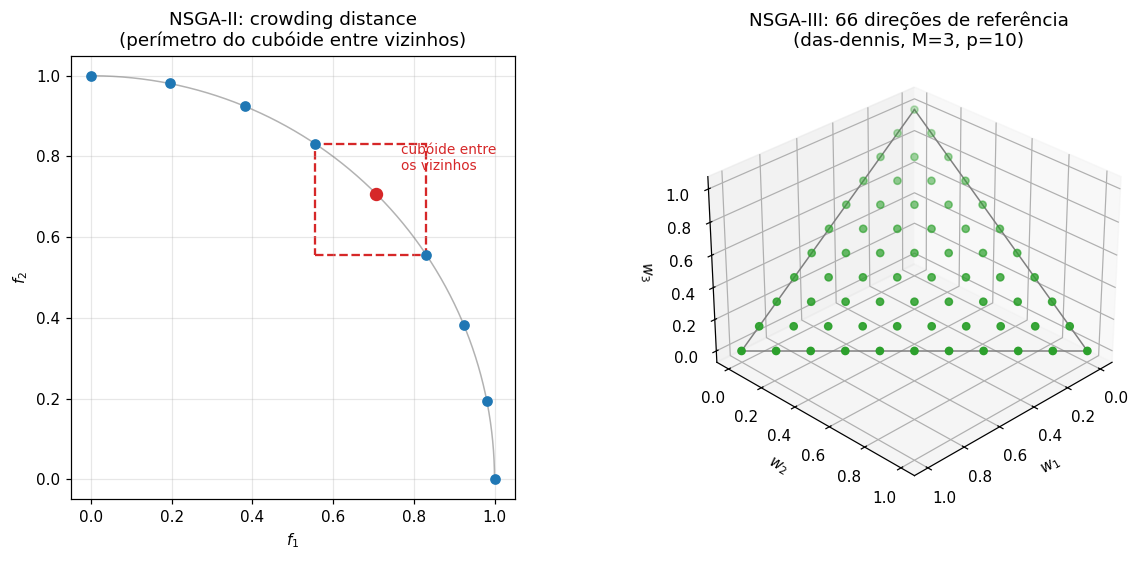

In [6]:
def generate_reference_points(M: int, p: int) -> np.ndarray:
    '''Malha das-dennis: pontos do simplexo com coordenadas múltiplas de 1/p que somam 1.'''
    def rec(points, num_objs, left, total, depth, cur):
        if depth == num_objs - 1:
            cur.append(left / total); points.append(cur.copy()); cur.pop()
        else:
            for i in range(left + 1):
                cur.append(i / total)
                rec(points, num_objs, left - i, total, depth + 1, cur)
                cur.pop()
    pts = []
    rec(pts, M, p, p, 0, [])
    return np.array(pts, dtype=float)

ref_dirs = generate_reference_points(M, DIV)   # usadas só pelo NSGA-III de referência

fig = plt.figure(figsize=(12, 5.2))
# (a) crowding distance em 2D
axc = fig.add_subplot(1, 2, 1)
_t = np.linspace(0, np.pi/2, 9)
_pf = np.vstack([np.cos(_t), np.sin(_t)]).T
axc.plot(*true_pf_m2(200), color="gray", lw=1, alpha=0.6)
axc.scatter(_pf[:, 0], _pf[:, 1], color="tab:blue", zorder=3)
j = 4
lo, hi = _pf[j-1], _pf[j+1]
axc.add_patch(plt.Rectangle((min(lo[0], hi[0]), min(lo[1], hi[1])),
                            abs(hi[0]-lo[0]), abs(hi[1]-lo[1]),
                            fill=False, ec="tab:red", ls="--", lw=1.5))
axc.scatter(*_pf[j], color="tab:red", zorder=4, s=60)
axc.annotate("cubóide entre\nos vizinhos", _pf[j], (_pf[j][0]+0.06, _pf[j][1]+0.06),
             color="tab:red", fontsize=9)
axc.set_title("NSGA-II: crowding distance\n(perímetro do cubóide entre vizinhos)")
axc.set_xlabel("$f_1$"); axc.set_ylabel("$f_2$"); axc.set_aspect("equal")
# (b) direções de referência do NSGA-III
axr = fig.add_subplot(1, 2, 2, projection="3d")
axr.scatter(ref_dirs[:, 0], ref_dirs[:, 1], ref_dirs[:, 2], s=22, color="tab:green")
for a, b in [(0, 1), (0, 2), (1, 2)]:
    e = np.zeros((2, 3)); e[0, a] = 1; e[1, b] = 1
    axr.plot(e[:, 0], e[:, 1], e[:, 2], color="gray", lw=1)
axr.set_title(f"NSGA-III: {len(ref_dirs)} direções de referência\n(das-dennis, M={M}, p={DIV})")
axr.set_xlabel("$w_1$"); axr.set_ylabel("$w_2$"); axr.set_zlabel("$w_3$")
axr.view_init(elev=30, azim=45)
plt.tight_layout(); plt.show()

## 4. Métricas de qualidade

Seja $A$ o conjunto devolvido por um algoritmo e $P^*$ a fronteira verdadeira (amostrada):

- **GD** (convergência): $\mathrm{GD}=\frac{1}{|A|}\big(\sum_{a\in A}\min_{p\in P^*}\lVert a-p\rVert^2\big)^{1/2}$. *Menor é melhor.*
- **IGD** (convergência + cobertura): $\mathrm{IGD}=\frac{1}{|P^*|}\sum_{p\in P^*}\min_{a\in A}\lVert p-a\rVert$. *Menor é melhor.*
- **Hipervolume (HV)** (convergência + diversidade, sem $P^*$): volume dominado por $A$ em relação a
  $r=(1.1,\dots)$. *Maior é melhor*; o HV do próprio $P^*$ é um teto prático.

In [7]:
from deap.tools._hypervolume import hv as _deap_hv

def generational_distance(A, P=None) -> float:
    P = PF_TRUE if P is None else P
    A = np.asarray(A, dtype=float)
    return float(np.sqrt(np.mean([np.min(np.sum((P - a) ** 2, axis=1)) for a in A])))

def inverted_generational_distance(A, P=None) -> float:
    P = PF_TRUE if P is None else P
    A = np.asarray(A, dtype=float)
    return float(np.mean([np.sqrt(np.min(np.sum((A - p) ** 2, axis=1))) for p in P]))

def hypervolume(A, ref=REF_HV) -> float:
    A = np.asarray(A, dtype=float)
    A = A[np.all(A <= ref, axis=1)]
    if len(A) == 0:
        return 0.0
    return float(_deap_hv.hypervolume(A, ref))

print("HV da fronteira verdadeira (teto prático, M=3):", round(hypervolume(PF_TRUE), 4))

HV da fronteira verdadeira (teto prático, M=3): 0.7903


### 4.1 Ilustração de GD e IGD

**GD** liga cada ponto aproximado (azul) à fronteira — mede o quão perto chegamos; **IGD** liga cada ponto
da fronteira (verde) ao aproximado mais próximo — mede o quão bem cobrimos a fronteira.

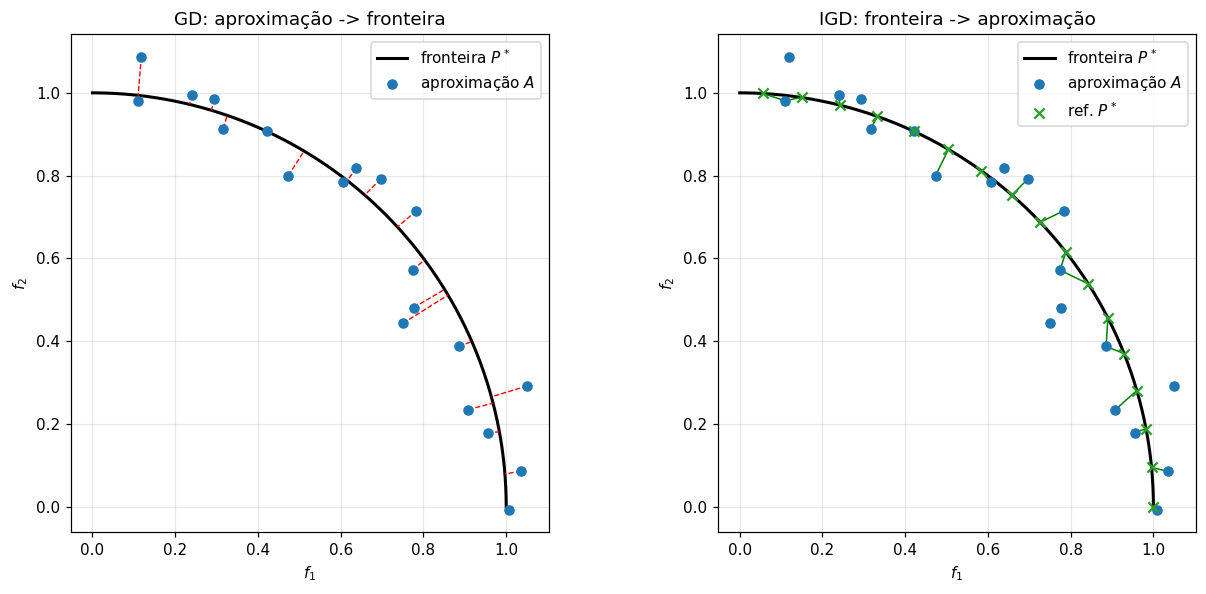

In [8]:
rng = np.random.default_rng(0)
_x, _y = true_pf_m2(200)
_pf2d = np.vstack([_x, _y]).T
_approx = _pf2d[::10] + rng.normal(0, 0.06, _pf2d[::10].shape)
_sample = _pf2d[::12]

fig, (axg, axi) = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, title in [(axg, "GD: aproximação -> fronteira"), (axi, "IGD: fronteira -> aproximação")]:
    ax.plot(_x, _y, "k-", lw=2, label="fronteira $P^*$")
    ax.set_title(title); ax.set_xlabel("$f_1$"); ax.set_ylabel("$f_2$"); ax.set_aspect("equal")
for a in _approx:
    nn = _pf2d[np.argmin(np.linalg.norm(_pf2d - a, axis=1))]
    axg.plot([a[0], nn[0]], [a[1], nn[1]], "r--", lw=0.9)
axg.scatter(_approx[:, 0], _approx[:, 1], c="tab:blue", s=35, label="aproximação $A$", zorder=3)
for p in _sample:
    nn = _approx[np.argmin(np.linalg.norm(_approx - p, axis=1))]
    axi.plot([p[0], nn[0]], [p[1], nn[1]], "g-", lw=1.0)
axi.scatter(_approx[:, 0], _approx[:, 1], c="tab:blue", s=35, label="aproximação $A$", zorder=3)
axi.scatter(_sample[:, 0], _sample[:, 1], c="tab:green", marker="x", s=45, label="ref. $P^*$", zorder=3)
axg.legend(loc="upper right"); axi.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 5. As quatro implementações e as correções no NSGA-II próprio

Todas expõem a **mesma assinatura** e devolvem a fronteira não-dominada final. Diferenças de mecanismo:

- **`NSGA-II`** (próprio), **`NSGA-II (DEAP)`**, **`NSGA-II (pymoo)`** usam *non-dominated sorting* +
  *crowding distance*; **`NSGA-III (ref.)`** usa direções de referência.
- Para uma comparação justa, todos partem da **mesma população inicial**, usam sobrevivência **(μ+λ)** e o
  pymoo recebe a **semente** de cada execução (parametrizado no módulo; ele também honra a população inicial
  via `sampling`).

**Análise e correção da implementação própria do NSGA-II.** Ao portar o diagnóstico do NSGA-III, encontramos
os mesmos padrões e os corrigimos em [`modules/nsga2`](../../modules/nsga2/nsga2.py):

1. **Viés de *crossover* (decisivo).** O laço usava apenas o primeiro filho do SBX (`children[0]`), que puxa
   cada gene para o menor dos pais ($\mathbb{E}[c_1]\approx\min$); isso enviesava as variáveis de distância
   para longe de $0{,}5$ e travava $g$. Passamos a usar **ambos os filhos**. Só isso derruba o GD de
   $\approx 0{,}53$ para $\approx 0{,}027$ — de "quebrado" a **empatado com DEAP e pymoo**.
2. **Seleção de pais por torneio binário.** A versão antiga sorteava pais **ao acaso**
   (`random.sample`). Trocamos pelo **torneio binário com *crowded-comparison*** (rank e, como desempate,
   maior *crowding distance*) — a seleção de acasalamento canônica do NSGA-II.
3. **Crowding distance normalizada por objetivo.** Passamos a dividir a contribuição de cada objetivo pela
   sua amplitude na fronteira, como no NSGA-II original (importa quando os objetivos têm escalas diferentes).

Com isso, a implementação própria do NSGA-II fica **canônica** e alinhada às bibliotecas.

In [9]:
from modules.nsga2 import nsga2_func
from modules.nsga3 import nsga3_func
from modules.nsga2_deap import nsga2_deap_func
from modules.nsga2_pymoo import nsga2_pymoo_func

# Três NSGA-II + NSGA-III como referência de qualidade.
ALGORITHMS = {
    "NSGA-II":          dict(fn=nsga2_func,       functions=dtlz2_objectives, kwargs={}),
    "NSGA-II (DEAP)":   dict(fn=nsga2_deap_func,  functions=dtlz2,            kwargs=dict(mu_plus_lambda=True)),
    "NSGA-II (pymoo)":  dict(fn=nsga2_pymoo_func, functions=dtlz2,            kwargs={}, pass_seed=True),
    "NSGA-III (ref.)":  dict(fn=nsga3_func,       functions=dtlz2,            kwargs=dict(ref_points=ref_dirs)),
}
COLORS = {"NSGA-II": "tab:blue", "NSGA-II (DEAP)": "tab:orange",
          "NSGA-II (pymoo)": "tab:red", "NSGA-III (ref.)": "tab:green"}

def sample_initial_population(seed):
    '''População inicial uniforme em [0,1]^n (M=3), reprodutível pela semente.'''
    random.seed(seed); np.random.seed(seed)
    return [np.array([random.uniform(b[0], b[1]) for b in bounds]) for _ in range(POP_SIZE)]

def run_algorithm(name, seed, initial_pop, algos=None):
    '''Executa uma implementação a partir da MESMA população inicial, reeinicializando
    os RNGs globais para uma comparação justa.'''
    algos = ALGORITHMS if algos is None else algos
    spec = algos[name]
    random.seed(seed); np.random.seed(seed)
    kw = dict(spec["kwargs"])
    if spec.get("pass_seed"):
        kw["seed"] = seed
    pf = spec["fn"](POP_SIZE, N_GEN, bounds, spec["functions"], crossover, mutation,
                    initial_pop=[p.copy() for p in initial_pop], **kw)
    return np.array(pf, dtype=float)

## 6. Execução detalhada (uma semente)

Rodamos as quatro implementações com a semente `SEED_DEMO` e a **mesma** população inicial.

In [10]:
init_demo = sample_initial_population(SEED_DEMO)
fronts = {}
print(f"Execução detalhada (semente = {SEED_DEMO}, M = {M})\n" + "-" * 56)
for name in ALGORITHMS:
    t = time.time()
    F = run_algorithm(name, SEED_DEMO, init_demo)
    dt = time.time() - t
    fronts[name] = F
    print(f"{name:18s} | pts={len(F):3d} | GD={generational_distance(F):.4f} | "
          f"IGD={inverted_generational_distance(F):.4f} | HV={hypervolume(F):.4f} | {dt:4.1f}s")

Execução detalhada (semente = 1, M = 3)
--------------------------------------------------------


NSGA-II            | pts= 66 | GD=0.0276 | IGD=0.0919 | HV=0.6646 |  7.0s


NSGA-II (DEAP)     | pts= 66 | GD=0.0262 | IGD=0.0836 | HV=0.6722 |  1.7s


NSGA-II (pymoo)    | pts= 66 | GD=0.0271 | IGD=0.0992 | HV=0.6494 |  1.0s


NSGA-III (ref.)    | pts= 66 | GD=0.0187 | IGD=0.0676 | HV=0.7128 |  6.3s


### 6.1 Fronteiras no espaço dos objetivos (3D)

Em cinza, a fronteira analítica (esfera). Note como os três NSGA-II cobrem a esfera de forma parecida entre
si, mas com as bordas/vértices menos povoados que o NSGA-III de referência.

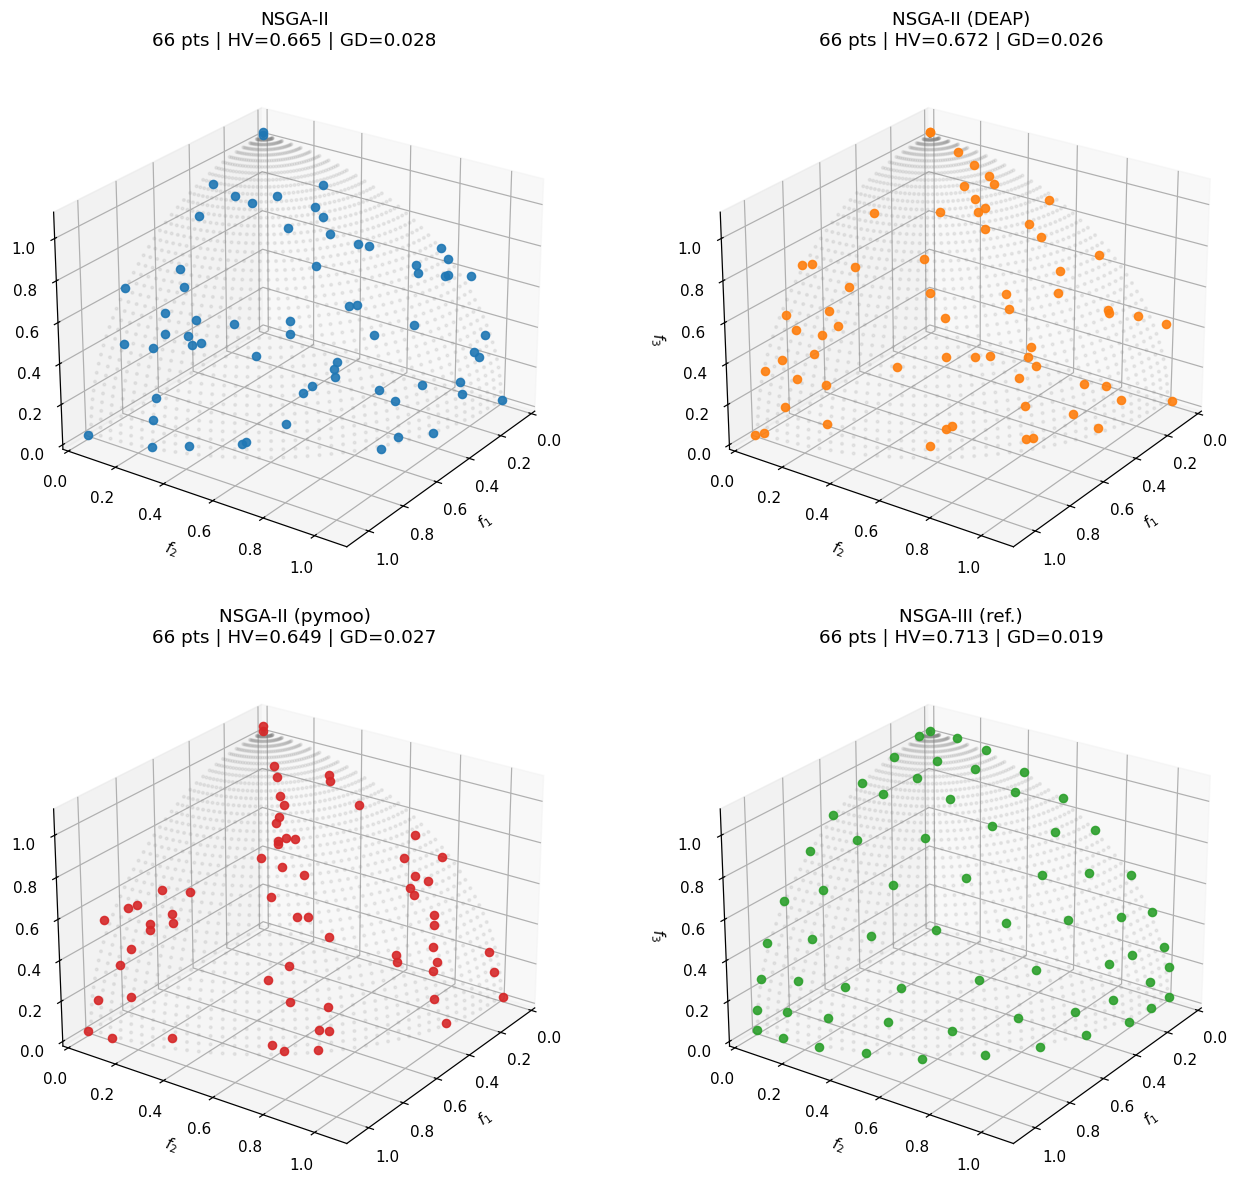

In [11]:
fig = plt.figure(figsize=(13, 11))
for idx, name in enumerate(ALGORITHMS, start=1):
    ax = fig.add_subplot(2, 2, idx, projection="3d")
    ax.scatter(PF_TRUE[:, 0], PF_TRUE[:, 1], PF_TRUE[:, 2], s=3, alpha=0.12, color="gray")
    F = fronts[name]
    ax.scatter(F[:, 0], F[:, 1], F[:, 2], s=28, alpha=0.9, color=COLORS[name], depthshade=False)
    ax.set_title(f"{name}\n{len(F)} pts | HV={hypervolume(F):.3f} | GD={generational_distance(F):.3f}")
    ax.set_xlabel("$f_1$"); ax.set_ylabel("$f_2$"); ax.set_zlabel("$f_3$")
    ax.view_init(elev=25, azim=35)
    for lim in (ax.set_xlim, ax.set_ylim, ax.set_zlim):
        lim(0, 1.1)
plt.tight_layout(); plt.show()

### 6.2 Projeções 2D par a par

A linha cinza é o contorno da fronteira analítica projetada (quarto de circunferência).

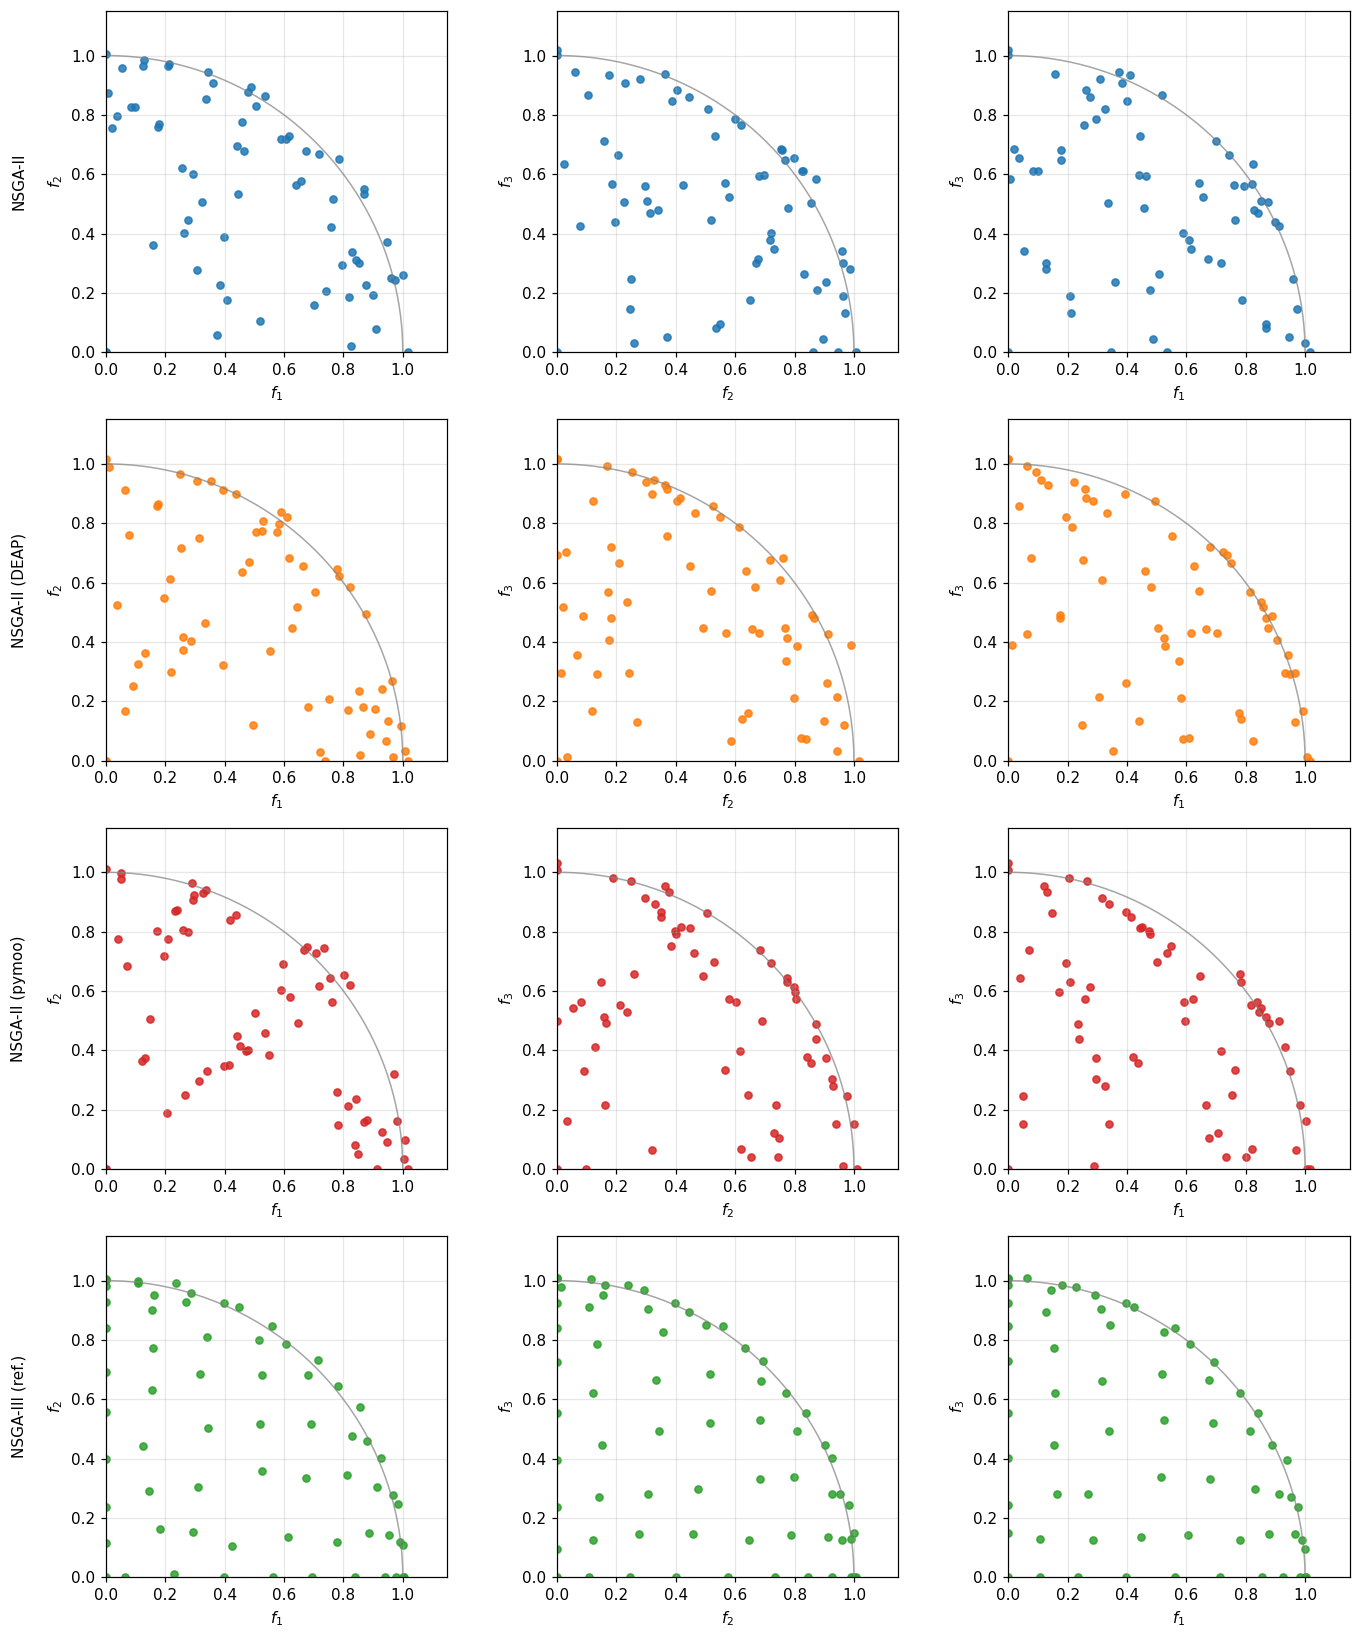

In [12]:
pairs = [(0, 1), (1, 2), (0, 2)]
qc_x, qc_y = true_pf_m2(200)
fig, axes = plt.subplots(len(ALGORITHMS), 3, figsize=(13, 15))
for r, name in enumerate(ALGORITHMS):
    F = fronts[name]
    for c, (i, j) in enumerate(pairs):
        ax = axes[r, c]
        ax.plot(qc_x, qc_y, color="gray", lw=1, alpha=0.7)
        ax.scatter(F[:, i], F[:, j], s=22, alpha=0.85, color=COLORS[name])
        ax.set_xlabel(f"$f_{i+1}$"); ax.set_ylabel(f"$f_{j+1}$")
        ax.set_xlim(0, 1.15); ax.set_ylim(0, 1.15); ax.set_aspect("equal")
        if c == 0:
            ax.set_ylabel(f"{name}\n\n$f_{j+1}$")
plt.tight_layout(); plt.show()

### 6.3 Coordenadas paralelas

Cada linha é uma solução; objetivos normalizados para $[0,1]$ dentro de cada fronteira.

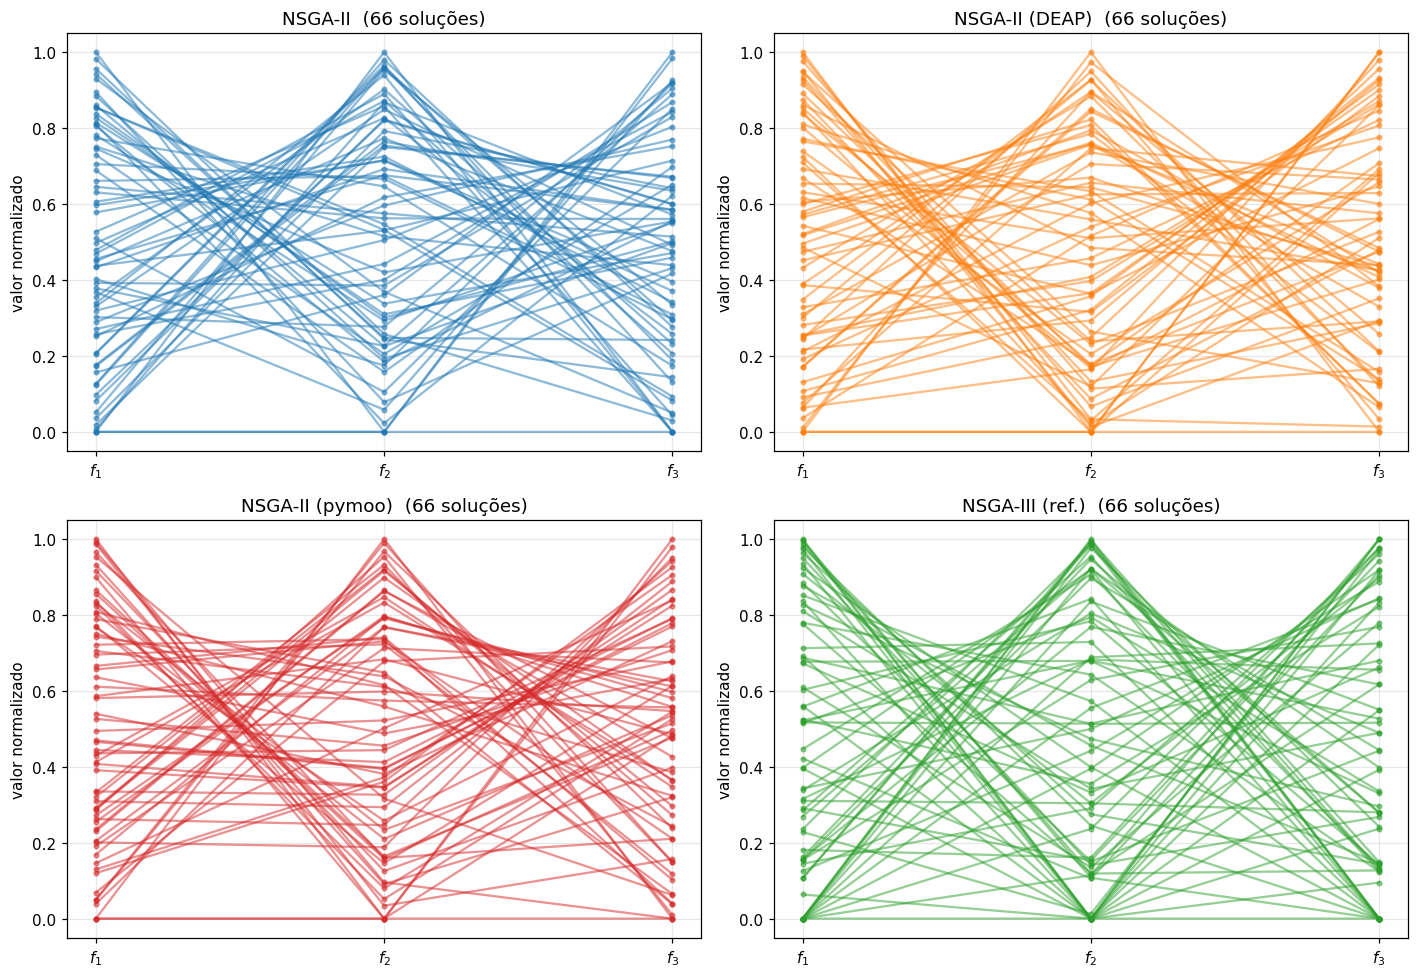

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, name in zip(axes.ravel(), ALGORITHMS):
    F = fronts[name]
    mn, mx = F.min(axis=0), F.max(axis=0)
    denom = np.where(mx - mn == 0, 1.0, mx - mn)
    S = (F - mn) / denom
    for row in S:
        ax.plot(range(M), row, marker="o", ms=3, alpha=0.5, color=COLORS[name])
    ax.set_xticks(range(M)); ax.set_xticklabels([f"$f_{i+1}$" for i in range(M)])
    ax.set_title(f"{name}  ({len(F)} soluções)"); ax.set_ylabel("valor normalizado")
plt.tight_layout(); plt.show()

## 7. Comparação estatística (várias sementes)

Repetimos para as sementes 1–11 e reportamos **média ± desvio padrão** de GD, IGD, HV e nº de pontos.

In [14]:
def run_study(algos, seeds, label=""):
    records = []
    t0 = time.time()
    for seed in seeds:
        init = sample_initial_population(seed)
        for name in algos:
            F = run_algorithm(name, seed, init, algos=algos)
            records.append(dict(algoritmo=name, semente=seed, n_pontos=len(F),
                                GD=generational_distance(F),
                                IGD=inverted_generational_distance(F),
                                HV=hypervolume(F)))
    print(f"{label}{len(seeds)} sementes x {len(algos)} algoritmos em {time.time()-t0:.1f}s")
    return pd.DataFrame(records)

def summarize(results, algos):
    summary = pd.DataFrame(index=list(algos))
    for col in ["GD", "IGD", "HV", "n_pontos"]:
        summary[f"{col} (média)"] = results.groupby("algoritmo")[col].mean()
        summary[f"{col} (dp)"] = results.groupby("algoritmo")[col].std().fillna(0.0)
    return summary.round(4)

results = run_study(ALGORITHMS, SEEDS)
summary = summarize(results, ALGORITHMS)
summary

11 sementes x 4 algoritmos em 178.6s


,GD (média),GD (dp),IGD (média),IGD (dp),HV (média),HV (dp),n_pontos (média),n_pontos (dp)
NSGA-II,0.0245,0.0028,0.0857,0.0035,0.6714,0.0091,66.0,0.0
NSGA-II (DEAP),0.0280,0.0032,0.0863,0.0043,0.6526,0.0084,66.0,0.0
NSGA-II (pymoo),0.0251,0.0025,0.0850,0.0058,0.6671,0.0098,66.0,0.0
NSGA-III (ref.),0.0195,0.0011,0.0681,0.0010,0.7097,0.0024,66.0,0.0


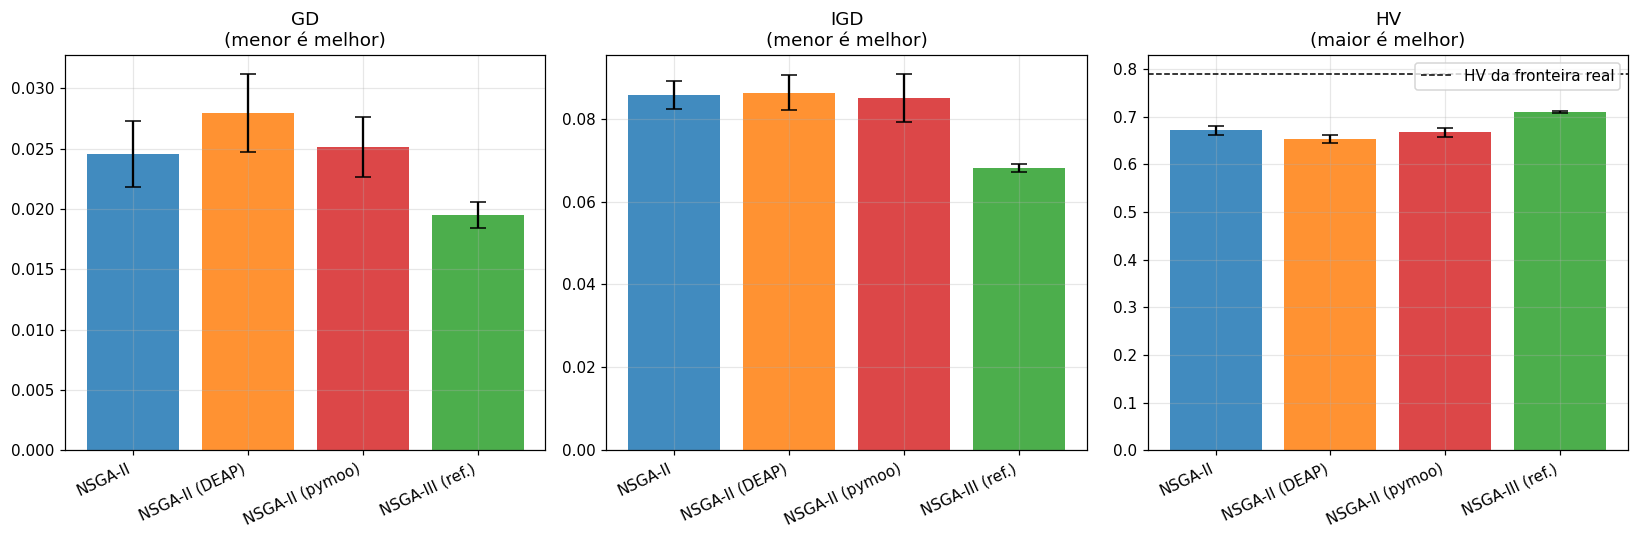

In [15]:
def plot_bars(results, algos, title=""):
    metrics = [("GD", "menor é melhor"), ("IGD", "menor é melhor"), ("HV", "maior é melhor")]
    names = list(algos)
    cols = [COLORS[n] for n in names]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (metric, hint) in zip(axes, metrics):
        m = [results.groupby("algoritmo")[metric].mean()[n] for n in names]
        s = [results.groupby("algoritmo")[metric].std().fillna(0.0)[n] for n in names]
        ax.bar(range(len(names)), m, yerr=s, capsize=5, color=cols, alpha=0.85)
        ax.set_title(f"{metric}\n({hint})")
        ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=25, ha="right")
        if metric == "HV":
            ax.axhline(hypervolume(PF_TRUE), color="k", ls="--", lw=1, label="HV da fronteira real")
            ax.legend()
    if title:
        fig.suptitle(title)
    plt.tight_layout(); plt.show()

plot_bars(results, ALGORITHMS)

## 8. NSGA-II na sua zona de conforto ($M=2$)

O NSGA-II foi concebido para **dois objetivos**, onde a *crowding distance* é muito eficaz. Repetimos o
estudo com $M=2$ (agora $n = 1 + k = 11$ variáveis; a fronteira é o quarto de circunferência). Aqui esperamos
que os três NSGA-II fiquem excelentes e **em pé de igualdade com o NSGA-III**.

In [16]:
# Reconfiguração para M = 2 (reaproveita operadores, métricas e infraestrutura)
M2 = 2
N_VAR2 = M2 - 1 + K            # = 11
bounds2 = [(0.0, 1.0)] * N_VAR2
REF_HV2 = np.array([1.1] * M2)

def dtlz2_m2(x):
    return dtlz2(x, M=M2)
dtlz2_m2_objectives = [(lambda x, m=m: float(dtlz2_m2(x)[m])) for m in range(M2)]

_x2, _y2 = true_pf_m2(400)
PF_TRUE_2 = np.vstack([_x2, _y2]).T

def gd2(A):  A = np.asarray(A, float); return float(np.sqrt(np.mean([np.min(np.sum((PF_TRUE_2 - a)**2, axis=1)) for a in A])))
def igd2(A): A = np.asarray(A, float); return float(np.mean([np.sqrt(np.min(np.sum((A - p)**2, axis=1))) for p in PF_TRUE_2]))
def hv2(A):
    A = np.asarray(A, float); A = A[np.all(A <= REF_HV2, axis=1)]
    return 0.0 if len(A) == 0 else float(_deap_hv.hypervolume(A, REF_HV2))

ref_dirs2 = generate_reference_points(M2, DIV)
ALGORITHMS_2 = {
    "NSGA-II":          dict(fn=nsga2_func,       functions=dtlz2_m2_objectives, kwargs={}),
    "NSGA-II (DEAP)":   dict(fn=nsga2_deap_func,  functions=dtlz2_m2,            kwargs=dict(mu_plus_lambda=True)),
    "NSGA-II (pymoo)":  dict(fn=nsga2_pymoo_func, functions=dtlz2_m2,            kwargs={}, pass_seed=True),
    "NSGA-III (ref.)":  dict(fn=nsga3_func,       functions=dtlz2_m2,            kwargs=dict(ref_points=ref_dirs2)),
}

print(f"HV da fronteira verdadeira (teto prático, M=2): {hv2(PF_TRUE_2):.4f}")

rows2 = []
init2 = None
fronts2 = {}
for seed in [1, 2, 3]:
    random.seed(seed); np.random.seed(seed)
    ip = [np.array([random.uniform(0.0, 1.0) for _ in range(N_VAR2)]) for _ in range(POP_SIZE)]
    for name in ALGORITHMS_2:
        spec = ALGORITHMS_2[name]
        random.seed(seed); np.random.seed(seed)
        kw = dict(spec["kwargs"])
        if spec.get("pass_seed"):
            kw["seed"] = seed
        pf = spec["fn"](POP_SIZE, N_GEN, bounds2, spec["functions"], crossover, mutation,
                        initial_pop=[p.copy() for p in ip], **kw)
        pf = np.array(pf, float)
        rows2.append(dict(algoritmo=name, semente=seed, n_pontos=len(pf),
                          GD=gd2(pf), IGD=igd2(pf), HV=hv2(pf)))
        if seed == 1:
            fronts2[name] = pf

df2 = pd.DataFrame(rows2)
summary2 = pd.DataFrame(index=list(ALGORITHMS_2))
for col in ["GD", "IGD", "HV", "n_pontos"]:
    summary2[f"{col} (média)"] = df2.groupby("algoritmo")[col].mean()
    summary2[f"{col} (dp)"] = df2.groupby("algoritmo")[col].std().fillna(0.0)
summary2.round(4)

HV da fronteira verdadeira (teto prático, M=2): 0.4236


,GD (média),GD (dp),IGD (média),IGD (dp),HV (média),HV (dp),n_pontos (média),n_pontos (dp)
NSGA-II,0.0029,0.0005,0.0081,0.0007,0.4150,0.0011,66.0,0.0
NSGA-II (DEAP),0.0029,0.0002,0.0081,0.0003,0.4145,0.0003,66.0,0.0
NSGA-II (pymoo),0.0028,0.0005,0.0082,0.0003,0.4147,0.0008,66.0,0.0
NSGA-III (ref.),0.0029,0.0007,0.0139,0.0010,0.4074,0.0025,66.0,0.0


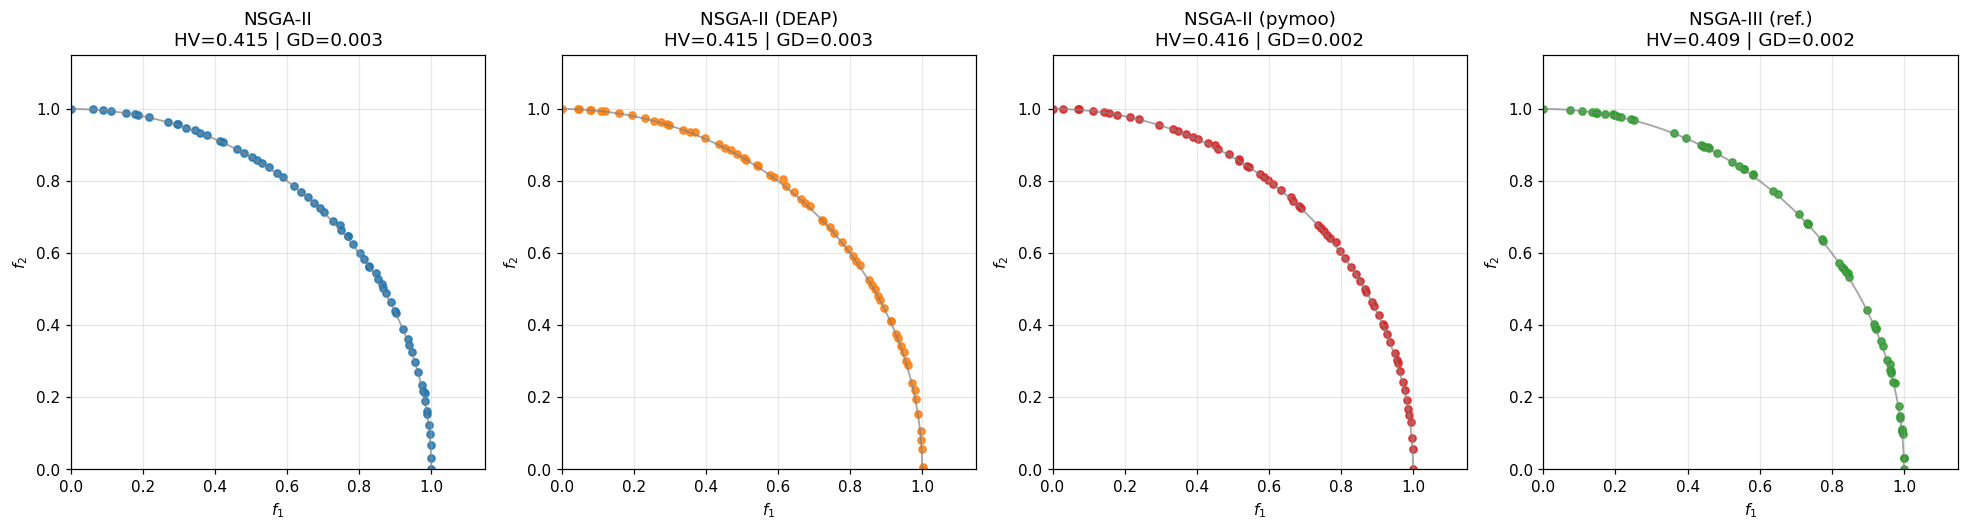

In [17]:
# Fronteiras M=2 (semente 1): todas devem cair sobre o quarto de circunferência
fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
for ax, name in zip(axes, ALGORITHMS_2):
    F = fronts2[name]
    ax.plot(_x2, _y2, color="gray", lw=1.2, alpha=0.7)
    ax.scatter(F[:, 0], F[:, 1], s=22, alpha=0.85, color=COLORS[name])
    ax.set_title(f"{name}\nHV={hv2(F):.3f} | GD={gd2(F):.3f}")
    ax.set_xlabel("$f_1$"); ax.set_ylabel("$f_2$")
    ax.set_xlim(0, 1.15); ax.set_ylim(0, 1.15); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 9. Discussão e conclusões

Sobre o DTLZ2, com operadores, população inicial e hiperparâmetros idênticos:

- **Em $M=3$, as três implementações de NSGA-II empatam** (GD ≈ 0,025; HV ≈ 0,66), com variância pequena e
  semelhante. Isso valida que a implementação própria (após as correções) está **correta** — o desempenho
  reflete o **algoritmo**, não um defeito de código.
- **O NSGA-II fica mensuravelmente atrás do NSGA-III** de referência em $M=3$ (GD ≈ 0,025 vs ≈ 0,020;
  HV ≈ 0,66 vs ≈ 0,71). A *crowding distance* cobre pior os **vértices/bordas** do octante do que as direções
  de referência — exatamente a limitação que motivou o NSGA-III. As projeções 2D e o 3D deixam isso visível.
- **Em $M=2$ (Seção 8), o NSGA-II brilha — e chega a superar o NSGA-III.** Os três NSGA-II caem sobre o
  quarto de circunferência com espaçamento **muito uniforme**, ao passo que os pontos do NSGA-III ficam
  visivelmente **agrupados/irregulares**; isso aparece nas métricas (IGD ≈ 0,008 do NSGA-II contra ≈ 0,014 do
  NSGA-III; HV ligeiramente maior no NSGA-II). Ou seja, o NSGA-II não é "pior" — é **melhor** na faixa para a
  qual foi projetado (2, e em geral poucos, objetivos) e só perde vantagem quando $M$ cresce.
- **As correções na implementação própria foram decisivas.** O ganho maior veio de **usar ambos os filhos do
  crossover** (GD de ≈ 0,53 para ≈ 0,027); o **torneio binário com *crowded-comparison*** e a **crowding
  distance normalizada** completaram o alinhamento ao NSGA-II canônico das bibliotecas.

**Mensagem geral.** Assim como no estudo do NSGA-III, o que separava a implementação própria das bibliotecas
eram **detalhes de arcabouço** (o viés de um filho só do crossover, a seleção de acasalamento, a normalização
da *crowding distance*) — não a "ideia" do algoritmo. Corrigidos, o NSGA-II próprio iguala DEAP e pymoo. E a
diferença **real e algorítmica** que resta — NSGA-II vs NSGA-III conforme $M$ cresce — aparece limpa e
mensurável: NSGA-III vence em muitos objetivos, NSGA-II vence em poucos.

### Próximos passos
- **Escalabilidade:** repetir para $M \in \{5, 8, 10\}$; a vantagem do NSGA-III sobre o NSGA-II tende a
  crescer com $M$.
- **Testes estatísticos:** aplicar Wilcoxon sobre GD/IGD/HV para confirmar o empate entre os três NSGA-II e a
  diferença para o NSGA-III.
- **Custo computacional:** medir tempo; as bibliotecas são muito mais rápidas que as implementações em Python
  puro ($O(N^2)$ na ordenação não-dominada).